## Plot Precipitation climatological daily cumulative sum

In [1]:
#%load_ext autoreload
#%autoreload 2
#%matplotlib inline

import xarray as xr
import matplotlib.pyplot as mp
import pandas as pd
#import geocat.comp as gc
#import seaborn as sb
import scipy as sp

import numpy as np
import os
import glob as gb
import dask

from matplotlib.cm import get_cmap
from matplotlib.dates import DateFormatter,MonthLocator
from matplotlib import cm
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import cartopy.feature as cf
from cartopy.io import shapereader
import geopandas


# Import
import importlib

### To Import My Functions ###
import daily_annual_cycle_calc as myplt

#import intake 
from distributed import Client
from ncar_jobqueue import NCARCluster

In [2]:

cluster = NCARCluster(project='P03010039',memory='32Gb',interface='ext', job_extra_directives=[], walltime ='12:00:00')
cluster.scale(18)
client = Client(cluster)
client



/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Future

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.191:34177,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/Casper_compute/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [3]:
'''
    SET UP CASE
'''

reg_name = 'AIR'

#case_names = ['GPCP','TRMM','CESM2','CESM3-125']
#case_names = ['AIR','GPCP','TRMM','CESM2']
#case_names = ['CAM7-L58','CESM3-127','CESM3-104','CESM3-98','CESM3-93','CESM3-82b','CESM2','TRMM','GPCP']
case_names = ['AIR','GPCP','TRMM','CMIP5']



var_name = 'PRECT' ; vscale = 86400.
years = ['2001','2008']
lpsave = True


fig_name = 'Onset_CMIP5_test'

# For the time/lat monsoon plot.FGOALS-g2_dmeans_ts_PRECT.nc
#lonm_w = 70 ; lonm_e = 100.
#latm_s = 0.; latm_n = 40. 





# Border of region for displaying map.
moffset = 10.




# Some run names
#crnums = ['001','002','003','004','005','006','007','008','009','010']
crnums = ['001','002','003','004','005']
#crnums = ['001']

#ernums =  ['0101','0151','0201','0251','0301']
ernums =  ['0101']

c5rnames = ['MIROC5','MPI-ESM-LR','ACCESS1-0','CESM1','CCSM4','NorESM1-M','FGOALS-g2']

## NOTES ##
# Good: ACCESS1-0, CanAM4, CESM1, CCSM4, NorESM, FGGOALS-g2,
# CESM1 is 1850 and has days since 0001-01-01
# EC-EARTH, bcc-csm1-1, CNRM-CM5, GFDL-CM3 has 366 days not 365 days per year.
# IPSL-CM5A-LR doy dimenstion 359???

### Regions ###

if reg_name == 'India':
    lonm_w = 70 ; lonm_e = 85.
    latm_s = 10.; latm_n = 35. 

if reg_name == 'W_Ind_Ocean':
    lonm_w = 52 ; lonm_e = 65.
    latm_s = -8.; latm_n = 5. 

if reg_name == 'AIR': # The rectilinear region but not the averaginng region.
    lonm_w = 72. ; lonm_e = 88.
    latm_s = 10. ; latm_n = 30. 

# Annual cycle options.
lat_lon = lonm_w,lonm_e,latm_s,latm_n,reg_name

print(lat_lon)

(72.0, 88.0, 10.0, 30.0, 'AIR')


In [6]:
## Directories

dir_obs = '/glade/cesm/amwg/amwg_data/obs_data/'
dir_e3sm = '/glade/campaign/cgd/ccr/E3SMv2/FV_regridded/'
dir_cesm2 = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/'
dir_cesm1 = '/glade/campaign/cesm/collections/cesmLE/CESM-CAM5-BGC-LE/atm/proc/tseries/daily'
dir_scratch = '/glade/derecho/scratch/rneale/'

dir_o = '/glade/work/rneale/data/'


'''
    Ensmble set dic
'''

# Set ensembles set dic and df.

rset_dic = {}
rset_dic['CMIP5'] = [dir_scratch+'CMIP5', c5rnames,'',years,'g','-',1.5]
rset_dic['E3SMv2'] = [dir_e3sm, ernums,'v2.FV1.historical_',years,'b','-',1.5]
rset_dic['E3SM'] = [dir_e3sm, ernums,'v2.FV1.historical_',years,'b','-',1.5]
rset_dic['CESM2'] =  [dir_cesm2,crnums,'b.e21.BHISTcmip6.f09_g17.LE2-1251.',years,'k','-',1.5]
rset_dic['CESM1'] =  [dir_cesm1,crnums,'b.e11.B20TRC5CNBDRD.f09_g16.',years,'r','-',1.5]

rset_dic['GPCP'] =  [dir_o,[''],'GPCP',years,'k','--',4]
rset_dic['TRMM'] =  [dir_o,[''],'TRMM',["2000","2009"],'k',':',4]
rset_dic['AIR'] =  [dir_o,[''],'AIR',years,'k','-.',4]

# Single runs of CAM7 or CESM3

rset_dic['CAM7-L58'] =  [dir_scratch,[''],'f.e30_cam6_4_036.FLTHIST.ne30_L58.001',years,'b','--',3]
rset_dic['CESM3-127'] =  [dir_scratch+'archive/',[''],'b.e30_beta05.BLT1850.ne30_t232_wgx3.127',years,'b','-',3]
rset_dic['CESM3-112'] =  [dir_scratch,[''],'b.e30_alpha03d.BLT1850.ne30_t232_wgx3.112',years,'b','-',3]
rset_dic['CESM3-104'] =  [dir_scratch,[''],'b.e30_beta02.BLT1850.ne30_t232.104',years,'r','-',3]
rset_dic['CESM3-98'] =  [dir_scratch,[''],'b.e23_alpha17f.BLT1850.ne30_t232.098',years,'m','-',3]
rset_dic['CESM3-93'] =  [dir_scratch,[''],'b.e23_alpha17f.BLT1850.ne30_t232.093',years,'c','-',3]
rset_dic['CESM3-82b'] =  [dir_scratch,[''],'b.e23_alpha16g.BLT1850.ne30_t232.082b',years,'g','-',3]
rset_dic['CESM3-156'] =  [dir_scratch+'archive/', [''],'b.e30_alpha06e.B1850C_LTso.ne30_t232_wgx3.156',years,'','-',3]



#Dataframe
# P_all is plot all lines separately in an ensemble and not an ensemble mean, otherwsie it is the e-mean line color.

rset_df = pd.DataFrame.from_dict(rset_dic, orient='index',
            columns=['ens_dir','ens_rnums','ens_pref','ens_years','p_linecol','p_ldash','p_lthick'])

leg_cols = rset_df.loc[case_names]['p_linecol'] 
leg_dash = rset_df.loc[case_names]['p_ldash'] 
#leg_lwidth =  rset_df.loc[case_names]['p_lthick']                  
leg_lines = [Line2D([0], [0], color=col, linewidth=4, linestyle=leg_dash[ic]) for ic,col in enumerate(leg_cols)]


'''
    Variable dic.     
'''

var_dic = {}
var_dic['PRECT'] = (vscale,lat_lon,['GPCP','TRMM','AIR'],['PREC','PRECT',''],[1.,1.,1.])
                          
# Dataframe                                                    
var_df = pd.DataFrame.from_dict(var_dic, orient='index', columns=['vscale','lon_lat','osource','onames','oscale'])                 

scolors = ['black','black','black','black','lightblue','lightgreen','lightcoral']

/glade/derecho/scratch/rneale/tmp/ipykernel_10658/3769594494.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  leg_lines = [Line2D([0], [0], color=col, linewidth=4, linestyle=leg_dash[ic]) for ic,col in enumerate(leg_cols)]


/glade/work/rneale/python/miniconda3/envs/neale_vproc/lib/python3.10/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "


 ---------- Variable = PRECT -----------

**************************************************************
* Ensemble set # 1  ( AIR ) -  1  ensemble simulations
* Asking for years  2001  to  2008
**************************************************************
AIR  -  1  ensemble members

- Ensemble run #  1
-- return_common_loc -- : Grabbing typical run path for AIR
-Dataset year Range = 19XX to 20XX


**************************************************************
* Ensemble set # 2  ( GPCP ) -  1  ensemble simulations
* Asking for years  2001  to  2008
**************************************************************
GPCP  -  1  ensemble members

- Ensemble run #  1
-- return_common_loc -- : Grabbing typical run path for GPCP
-Dataset year Range =  <xarray.DataArray 'year' ()> Size: 8B
array(1996)
Coordinates:
    time     datetime64[ns] 8B 1996-10-01T12:00:00
Attributes:
    long_name:  time  to  <xarray.DataArray 'year' (time: 6513)> Size: 52kB
array([1996, 1996, 1996, ..., 2014, 2014, 2

/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:205: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  dset = xr.open_mfdataset(run_names)




**************************************************************
* Ensemble set # 4  ( CMIP5 ) -  7  ensemble simulations
* Asking for years  2001  to  2008
**************************************************************
CMIP5  -  7  ensemble members

- Ensemble run #  1
-- return_common_loc -- : Grabbing typical run path for CMIP5
/glade/derecho/scratch/rneale/CMIP5/MIROC5_dmeans_ts_PRECT.nc
-Dataset year Range =  <xarray.DataArray 'year' ()> Size: 8B
array(1979)
Coordinates:
    time     object 8B 1979-01-01 12:00:00
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds  to  <xarray.DataArray 'year' (time: 9855)> Size: 79kB
array([1979, 1979, 1979, ..., 2005, 2005, 2005])
Coordinates:
  * time     (time) object 79kB 1979-01-01 12:00:00 ... 2005-12-31 12:00:00
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds
Mask Generated for  CMIP5
<xarray.DataArray 'PRECT' (ti

/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:205: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  dset = xr.open_mfdataset(run_names)


...

/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:205: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  dset = xr.open_mfdataset(run_names)



- Ensemble run #  6
-- return_common_loc -- : Grabbing typical run path for CMIP5
/glade/derecho/scratch/rneale/CMIP5/NorESM1-M_dmeans_ts_PRECT.nc
-Dataset year Range =  <xarray.DataArray 'year' ()> Size: 8B
array(1979)
Coordinates:
    time     object 8B 1979-01-01 12:00:00
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds  to  <xarray.DataArray 'year' (time: 9855)> Size: 79kB
array([1979, 1979, 1979, ..., 2005, 2005, 2005])
Coordinates:
  * time     (time) object 79kB 1979-01-01 12:00:00 ... 2005-12-31 12:00:00
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds
Mask Generated for  CMIP5
<xarray.DataArray 'PRECT' (time: 1825)> Size: 15kB
dask.array<mean_agg-aggregate, shape=(1825,), dtype=float64, chunksize=(1825,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 15kB 2001-01-01 12:00:00 ... 2005-12-31 12:00:00


/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:205: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  dset = xr.open_mfdataset(run_names)



- Ensemble run #  7
-- return_common_loc -- : Grabbing typical run path for CMIP5
/glade/derecho/scratch/rneale/CMIP5/FGOALS-g2_dmeans_ts_PRECT.nc
-Dataset year Range =  <xarray.DataArray 'year' ()> Size: 8B
array(1979)
Coordinates:
    time     object 8B 1979-01-01 12:00:00
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds  to  <xarray.DataArray 'year' (time: 9855)> Size: 79kB
array([1979, 1979, 1979, ..., 2005, 2005, 2005])
Coordinates:
  * time     (time) object 79kB 1979-01-01 12:00:00 ... 2005-12-31 12:00:00
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds
Mask Generated for  CMIP5
<xarray.DataArray 'PRECT' (time: 1825)> Size: 15kB
dask.array<mean_agg-aggregate, shape=(1825,), dtype=float64, chunksize=(1825,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) object 15kB 2001-01-01 12:00:00 ... 2005-12-31 12:00:00


/glade/work/rneale/git/python-scripts/monsoons/CMIP_onset/daily_annual_cycle_calc.py:205: SerializationWarning: Unable to decode time axis into full numpy.datetime64[ns] objects, continuing using cftime.datetime objects instead, reason: dates out of range. To silence this warning use a coarser resolution 'time_unit' or specify 'use_cftime=True'.
  dset = xr.open_mfdataset(run_names)


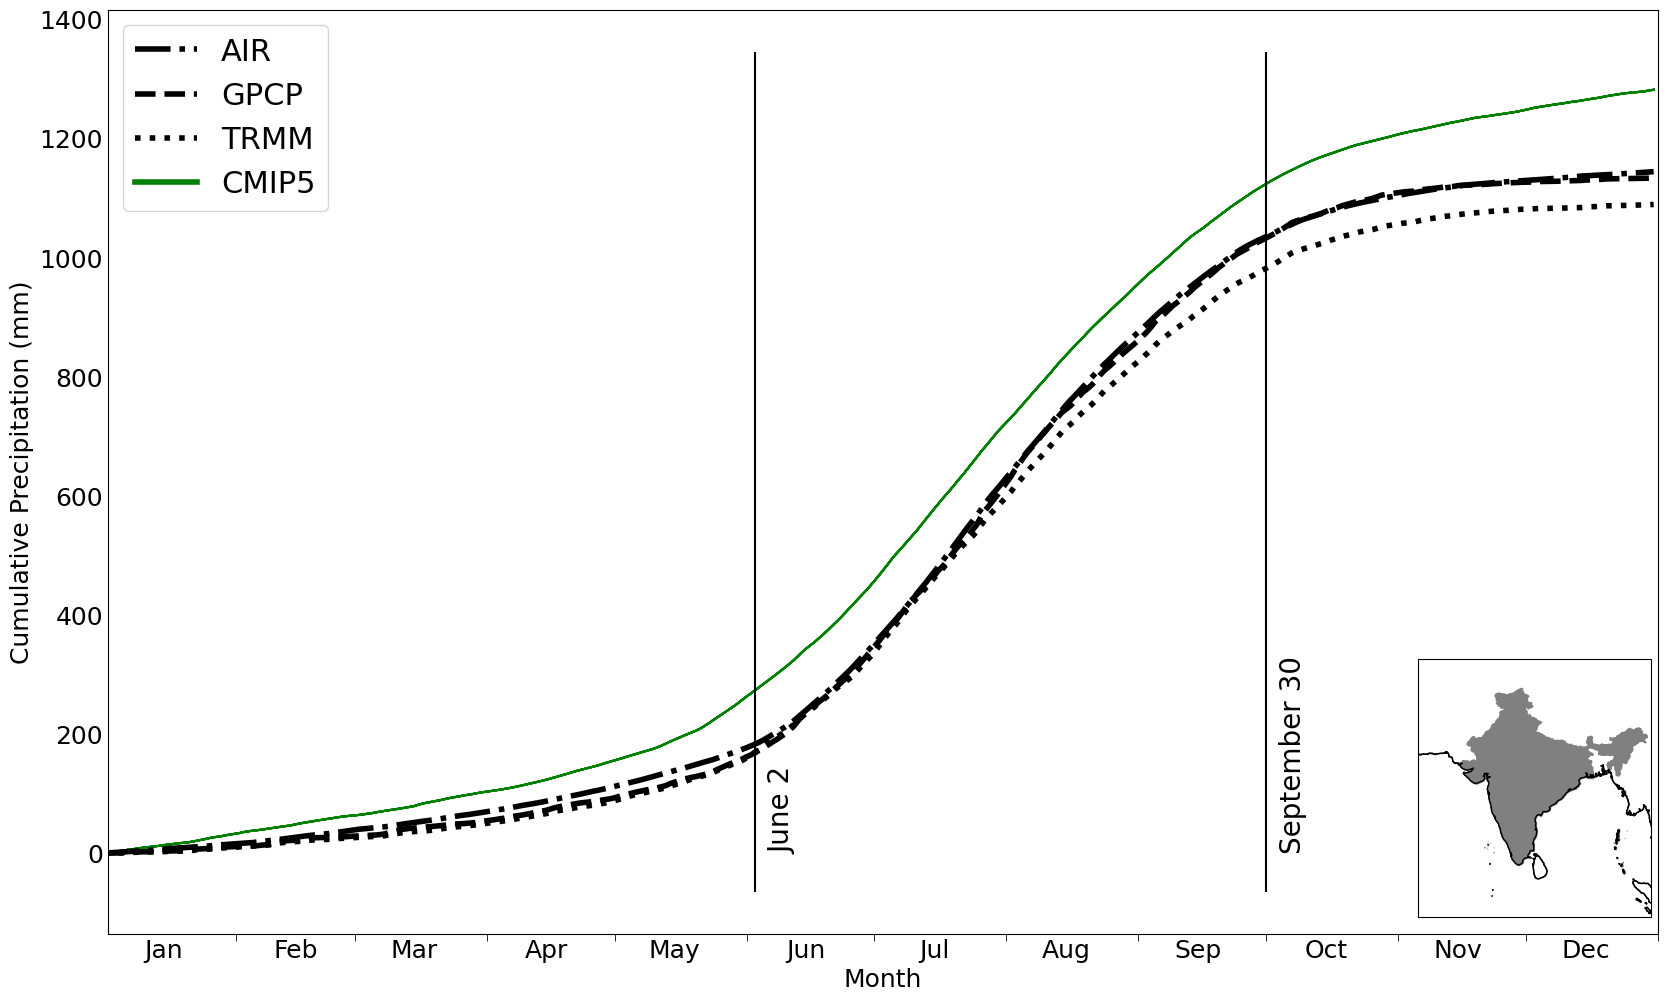

In [8]:
importlib.reload(myplt) # Required because I am constantly editing scam_func.py

fig, ax = mp.subplots(figsize=(20,12))

# Plot the inset of the high resolution India mask
axins = myplt.region_mask(ax,lat_lon,lmask=True)

#land_10m = NaturalEarthFeature('physical', 'land', '10m')


print(' ---------- Variable = '+var_name+' -----------')

for icase,cname in enumerate(case_names):
    
    nens = len(rset_df.loc[cname]['ens_rnums']) # Num. Ensmble simulations
    
    print('')
    print('**************************************************************')
    print('* Ensemble set #',icase+1,' (',cname,') - ',nens,' ensemble simulations')
    print('* Asking for years ',years[0],' to ',years[1])
    print('**************************************************************')
          
    rset = rset_df.loc[cname]   
    
        
    '''
        Routine for reading in data and calculating annual cycle from daily data
    '''
    
    var_data = myplt.calc_daily_acycle(reg_name,cname,rset_df,var_df) # rest dic and ens index   

    
    '''
        Line plotting 
    '''

    # Important options is whether to plot ensembles individually or as lines
    
    linecol = rset_df.loc[cname]['p_linecol']    
    ldash = rset_df.loc[cname]['p_ldash']    
    lthick = rset_df.loc[cname]['p_lthick']    
    porder = 5 if cname in var_df.loc[var_name]['osource'] else 1
    
       
    #%time for iens in range(0,nens) : ax.plot(var_data[iens,:],color=linecol,linestyle=ldash,linewidth=lthick,zorder=porder)

    for iens in range(0,nens) : ax.plot(var_data.mean(dim="ens_num"),color=linecol,linestyle=ldash,linewidth=lthick,zorder=porder)

#    if nens != 1 and linecol != 'all': 
#        print(scolors[icase])
#        ax.fill_between(var_data.dayofyear, var_data.min(dim="ens_num"), var_data.max(dim="ens_num"), color=scolors[icase], alpha=.2)

    
'''
    Set Axes And Legend
'''

date_form = DateFormatter("%b")

ax.xaxis.set_major_locator(MonthLocator(bymonthday=15))
ax.xaxis.set_minor_locator(MonthLocator())
ax.xaxis.set_major_formatter(date_form)

ax.set_xlim([1,365]) 
yr = ax.get_ylim()
ax.vlines(153, yr[0], yr[1], color='black', linestyle='-') # Jun 2
ax.vlines(273, yr[0], yr[1], color='black', linestyle='-') # Spe 30

ax.text(156, 0, "June 2", rotation=90, verticalalignment='bottom',fontsize=20)
ax.text(276, 0, "September 30", rotation=90, verticalalignment='bottom',fontsize=20)

ax.tick_params(which='major', length=0)
ax.tick_params(which='minor', length=5)
ax.set_xlabel('Month', fontsize=18)
ax.set_ylabel('Cumulative Precipitation (mm)', fontsize=18)
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)




ax.legend(leg_lines, case_names,loc='upper left',fontsize=22)
mp.savefig(fig_name+'_daily_prect_cdf_'+reg_name+'.png', dpi=70)  
    